<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Загрузка-и-обработка" data-toc-modified-id="Загрузка-и-обработка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Загрузка и обработка</a></span></li><li><span><a href="#Парсер-критериев" data-toc-modified-id="Парсер-критериев-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Парсер критериев</a></span></li><li><span><a href="#Фильтрация-объявлений" data-toc-modified-id="Фильтрация-объявлений-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Фильтрация объявлений</a></span></li><li><span><a href="#Замена-параметров-в-объявлениях-по-словарям" data-toc-modified-id="Замена-параметров-в-объявлениях-по-словарям-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Замена параметров в объявлениях по словарям</a></span></li><li><span><a href="#Изменение-колонок" data-toc-modified-id="Изменение-колонок-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Изменение колонок</a></span></li><li><span><a href="#Построение-модели-LGBMClassifier" data-toc-modified-id="Построение-модели-LGBMClassifier-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Построение модели LGBMClassifier</a></span></li><li><span><a href="#Построение-модели-XGBoost" data-toc-modified-id="Построение-модели-XGBoost-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Построение модели XGBoost</a></span></li><li><span><a href="#Применение-gpt" data-toc-modified-id="Применение-gpt-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Применение gpt</a></span></li></ul></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import csv
import sys
import pickle
from dotenv import load_dotenv
import os
import requests
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import shap
from datetime import datetime
import psycopg2
from psycopg2.extras import RealDictCursor
from llama_cpp import Llama
RANDOM_STATE = 1

## Загрузка и обработка

In [2]:
max_int = sys.maxsize
while True:
    try:
        csv.field_size_limit(max_int)
        break
    except OverflowError:
        max_int = int(max_int / 10)

In [3]:
car_data = pd.read_csv('order_underwriting_checks.csv', sep=",", engine='python')

In [4]:
dict_body = pd.read_csv('Словари_Данных_Объявлений\dict_body_type_202512021406.csv', sep=",", engine='python')
dict_color = pd.read_csv('Словари_Данных_Объявлений\dict_color_202512021406.csv', sep=",", engine='python')
dict_condition = pd.read_csv('Словари_Данных_Объявлений\dict_condition_status_202512021409.csv', sep=",", engine='python')
dict_custom_status = pd.read_csv('Словари_Данных_Объявлений\dict_custom_status_202512021409.csv', sep=",", engine='python')
dict_drive_type = pd.read_csv('Словари_Данных_Объявлений\dict_drive_type_202512021409.csv', sep=",", engine='python')
dict_engine_type = pd.read_csv('Словари_Данных_Объявлений\dict_engine_type_202512021410.csv', sep=",", engine='python')
dict_generation = pd.read_csv('Словари_Данных_Объявлений\dict_generation_202512021410.csv', sep=",", engine='python')
dict_mark = pd.read_csv('Словари_Данных_Объявлений\dict_mark_202512021410.csv', sep=",", engine='python')
dict_model = pd.read_csv('Словари_Данных_Объявлений\dict_model_202512021410.csv', sep=",", engine='python')
dict_model_noramlized = pd.read_csv('Словари_Данных_Объявлений\dict_model_normalized_202512021410.csv', sep=",", engine='python')
dict_source = pd.read_csv('Словари_Данных_Объявлений\dict_source_202512021410.csv', sep=",", engine='python')
dict_transmission = pd.read_csv('Словари_Данных_Объявлений\dict_transmission_type_202512021410.csv', sep=",", engine='python')
dict_wheel_type = pd.read_csv('Словари_Данных_Объявлений\dict_wheel_type_202512021410.csv', sep=",", engine='python')

In [5]:
dict_transmission = dict_transmission.replace(['автомат', 'Автомат'], 'АКПП')
dict_body = dict_body.replace('пятидверный внедорожник', 'внедорожник 5 дв.')
dict_body = dict_body.replace('трехдверный внедорожник', 'внедорожник 3 дв.')
dict_body = dict_body.replace('пятидверный хэтчбэк', 'хэтчбек 5 дв.')
dict_body = dict_body.replace('трехдверный хэтчбэк', 'хэтчбек 3 дв.')

In [ ]:
car_data.head(3)

In [ ]:
car_data['desired_criteria'][4000]

In [8]:
car_data.columns

Index(['id', 'order_id', 'desired_criteria', 'alternative_criteria',
       'manager_comment', 'under_comment', 'underwriter_name',
       'service_change', 'supervisor_auto_correct', 'supervisor_comment',
       'denial_reason', 'matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'offers_count', 'ads_market_count',
       'market_saturation_coefficient', 'region', 'recommended_links',
       'inspected_links', 'ads_links', 'ads_query_debug', 'ads_data',
       'underwriting_score', 'auto_underwriting_verdict',
       'manual_underwriting_verdict', 'manual_review_required', 'auto_comment',
       'created_at', 'ai_underwriting_verdict', 'chatgpt_vehicle_verdict'],
      dtype='object')

In [9]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6717 entries, 0 to 6716
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             6717 non-null   int64  
 1   order_id                       6717 non-null   int64  
 2   desired_criteria               6713 non-null   object 
 3   alternative_criteria           6711 non-null   object 
 4   manager_comment                4192 non-null   object 
 5   under_comment                  6504 non-null   object 
 6   underwriter_name               4295 non-null   object 
 7   service_change                 6717 non-null   int64  
 8   supervisor_auto_correct        238 non-null    float64
 9   supervisor_comment             921 non-null    object 
 10  denial_reason                  0 non-null      float64
 11  matched_orders_count           6717 non-null   int64  
 12  inspected_cars_count           6717 non-null   i

In [ ]:
print(car_data['ads_query_debug'][4000])

In [11]:
car_data = car_data.dropna(subset=['manual_underwriting_verdict'])
car_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6548 entries, 0 to 6713
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             6548 non-null   int64  
 1   order_id                       6548 non-null   int64  
 2   desired_criteria               6544 non-null   object 
 3   alternative_criteria           6543 non-null   object 
 4   manager_comment                4192 non-null   object 
 5   under_comment                  6504 non-null   object 
 6   underwriter_name               4295 non-null   object 
 7   service_change                 6548 non-null   int64  
 8   supervisor_auto_correct        238 non-null    float64
 9   supervisor_comment             905 non-null    object 
 10  denial_reason                  0 non-null      float64
 11  matched_orders_count           6548 non-null   int64  
 12  inspected_cars_count           6548 non-null   int64 

## Сохранение тестового запроса

In [ ]:
car_data_to_test_script = car_data.loc[5555]
car_data_to_test_script.to_frame().T.to_csv('test_ad.csv', index=False)
car_data_to_test_script.to_frame().T

In [ ]:
test_ad = pd.read_csv('test_ad.csv', engine='python')
test_ad

In [ ]:
car_data.columns

Часть колонок исключаем, колонки с просто ссылками также исключаем, в них нет информции по автомобилю

In [15]:
car_data_modified = car_data[['desired_criteria',
       'service_change',
       'matched_orders_count', 
       'inspected_cars_count',
       'recommended_cars_count', 
       'offers_count',
       'ads_market_count',
       'market_saturation_coefficient',
       'region',
       'ads_data',
       'manual_underwriting_verdict']]
car_data_modified.reset_index(inplace=True)

In [ ]:
car_data_modified.head(5)

In [17]:
car_data_modified = car_data_modified.dropna(subset='desired_criteria')

In [ ]:
car_data_modified['desired_criteria'][5]

## Парсер критериев

In [19]:
def parse_criteria(text):
    data = {'brand': 'Любая',
            'model': 'Любая',
            'year': np.nan,
            'generation': 'Nan',
            'mileage': 1101,
            'budget': np.nan,
            'max_owners': np.nan,
            'min_volume': np.nan,
            'max_volume': np.nan,
            'trasmission': 'Любая',
            'engine_type': 'Любой',
            'body_type': 'Любой',
            'wheel_drive': 'Любой',
            'color': 'Любой',
            'complectation': 'Любая',
            'comment': 'Любая'}
    parts = [part.strip() for part in text.split(';') if part.strip()]
    for part in parts:
        if part.lower().startswith('марка'):
            key = 'brand'
            data[key] = part[5:].strip()
        elif part.lower().startswith('модель'):
            key = 'model'
            data[key] = part[6:].strip()
        elif part.lower().startswith('год от'):
            key = 'year'
            data[key] = int(re.sub(r'год от\s*', '', part).strip())
        elif part.lower().startswith('поколение'):
            key = 'generation'
            data[key] = re.sub(r'поколение\s*', '', part).strip()
        elif part.lower().startswith('пробег до'):
            key = 'mileage'
            data[key] = int(re.search(r'пробег\s+до\s+(\d+)', part).group(1))
        elif part.lower().startswith('бюджет до'):
            key = 'budget'
            data[key] = int(re.search(r'бюджет\s+до\s+(\d+)', part).group(1))
        elif part.lower().startswith('владельцев до'):
            key = 'max_owners'
            data[key] = int(re.sub(r'владельцев до\s*', '', part).split('\n', 1)[0].strip())
        elif part.lower().startswith('объем'):
            match = re.search(r'от\s*(\d+(?:\.\d+)?)\s*до\s*(\d+(?:\.\d+)?)', part)
            if match:
                key = 'min_volume'
                data[key] = float(match.group(1))  # 2.0 (или 2.5)
                key = 'max_volume'
                data[key] = float(match.group(2))  # 3.0 (или 3.7)
        elif part.lower().startswith('трансмиссия'):
            key = 'trasmission'
            text = re.sub(r'трансмиссия\s*', '', part).strip()
            data[key] = text[:text.find('\n')] if '\n' in text else text
        elif part.lower().startswith('двигатель'):
            key = 'engine_type'
            text = re.sub(r'двигатель\s*', '', part).strip()
            data[key] = text[:text.find('\n')] if '\n' in text else text
        elif part.lower().startswith('кузов'):
            key = 'body_type'
            text = re.sub(r'кузов\s*', '', part).strip().lower()
            data[key] = (text[:text.find('\n')] if '\n' in text else text).strip().strip(',')
        elif part.lower().startswith('привод'):
            key = 'wheel_drive'
            text = re.sub(r'привод\s*', '', part).strip()
            data[key] = text[:text.find('\n')] if '\n' in text else text
        elif part.lower().startswith('комплектация'):
            key = 'complectation'
            text = re.sub(r'комплектация\s*', '', part).strip()
            data[key] = text[:text.find('\n')] if '\n' in text else text
        elif part.lower().startswith('комментарий'):
            key = 'comment'
            data[key] = re.sub(r'комментарий\s*', '', part).strip()
        elif part.lower().startswith('цвет'):
            key = 'color'
            text = re.sub(r'цвет\s*', '', part).strip().lower()
            text = text.replace('черный', 'чёрный')
            text = text.replace('желтый', 'жёлтый')
            data[key] = text[:text.find('\n')] if '\n' in text else text
    if data['mileage'] == 1101:
        if datetime.now().year - 1 > data['year']:
            data['mileage'] = np.nan
    return data
def criteria_to_series(text):
    data = parse_criteria(text)
    return pd.Series(data)

In [20]:
criteria_to_series(car_data_modified['desired_criteria'][5])

brand                                                      Porsche
model                                                        Macan
year                                                          2019
generation                                  Поколение I Рестайлинг
mileage                                                     100000
budget                                                     5500000
max_owners                                                       2
min_volume                                                     NaN
max_volume                                                     NaN
trasmission                                                  робот
engine_type                                                 бензин
body_type                                              внедорожник
wheel_drive                                                 полный
color                                                        Любой
complectation    Желательно удержание в полосе, подогрев задни

In [21]:
car_data_modified[['brand', 'model', 'year', 'generation', 'mileage', 'budget', 'max_owners', 'min_volume', 'max_volume',
       'trasmission', 'engine_type', 'body_type', 'wheel_drive', 'color', 
       'complectation', 'comment']] = car_data_modified['desired_criteria'].apply(criteria_to_series)

In [ ]:
car_data_modified.head(5)

In [23]:
car_data_modified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6544 entries, 0 to 6547
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          6544 non-null   int64  
 1   desired_criteria               6544 non-null   object 
 2   service_change                 6544 non-null   int64  
 3   matched_orders_count           6544 non-null   int64  
 4   inspected_cars_count           6544 non-null   int64  
 5   recommended_cars_count         6544 non-null   int64  
 6   offers_count                   6544 non-null   int64  
 7   ads_market_count               3126 non-null   float64
 8   market_saturation_coefficient  3036 non-null   float64
 9   region                         6544 non-null   object 
 10  ads_data                       1455 non-null   object 
 11  manual_underwriting_verdict    6544 non-null   object 
 12  brand                          6544 non-null   object

In [24]:
def parse_ad(text):
    if text == text:
        try:
            ads = json.loads(text)
        except json.JSONDecodeError:
            print(f"Json обрывается:\n {text[:150]}...")
            pos = text.rfind('"}')
            if pos != -1:
                text = text[:pos + 2] + ']'
            ads = json.loads(text)
        return ads
    else:
        return text

In [25]:
car_data_modified['ads_data'] = car_data_modified['ads_data'].apply(parse_ad)

In [26]:
def replace_body_types(text):
    text = text.replace('универсал 5 дв.', 'универсал')
    text = text.replace('хэтчбек 5 дв.', 'хэтчбек 4 дв.')
    return text
car_data_modified['body_type'] = car_data_modified['body_type'].apply(replace_body_types)
def replace_model_types(text):
    text = text.replace('ГАЗель (3302)', 'ГАЗель 3302')
    text = text.replace('Cee\'d', 'Ceed')
    return text
car_data_modified['model'] = car_data_modified['model'].apply(replace_model_types)

In [27]:
car_data_modified = car_data_modified[car_data_modified['brand'] != 'любая']
car_data_modified = car_data_modified[car_data_modified['model'] != 'любая']
car_data_modified.reset_index(inplace=True)

In [28]:
car_data_modified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6520 entries, 0 to 6519
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   level_0                        6520 non-null   int64  
 1   index                          6520 non-null   int64  
 2   desired_criteria               6520 non-null   object 
 3   service_change                 6520 non-null   int64  
 4   matched_orders_count           6520 non-null   int64  
 5   inspected_cars_count           6520 non-null   int64  
 6   recommended_cars_count         6520 non-null   int64  
 7   offers_count                   6520 non-null   int64  
 8   ads_market_count               3117 non-null   float64
 9   market_saturation_coefficient  3034 non-null   float64
 10  region                         6520 non-null   object 
 11  ads_data                       1452 non-null   object 
 12  manual_underwriting_verdict    6520 non-null   o

## Построение графиков

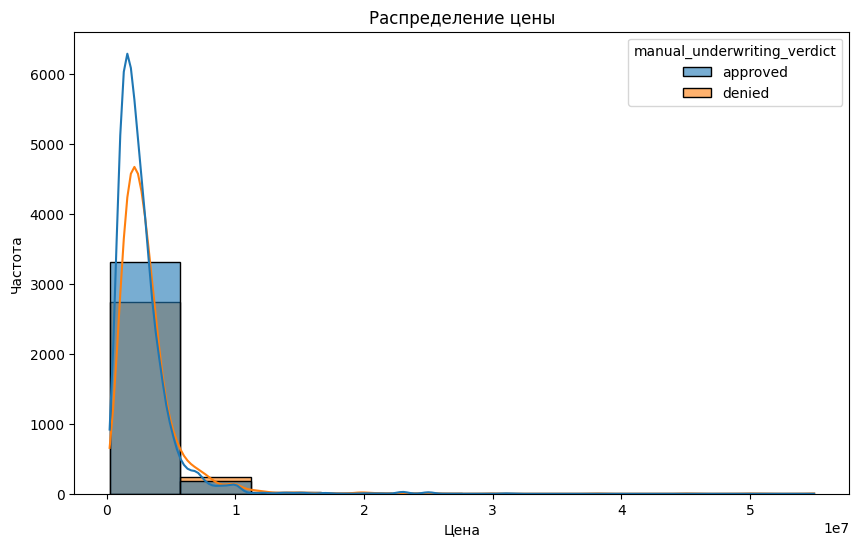

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='budget',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение цены')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

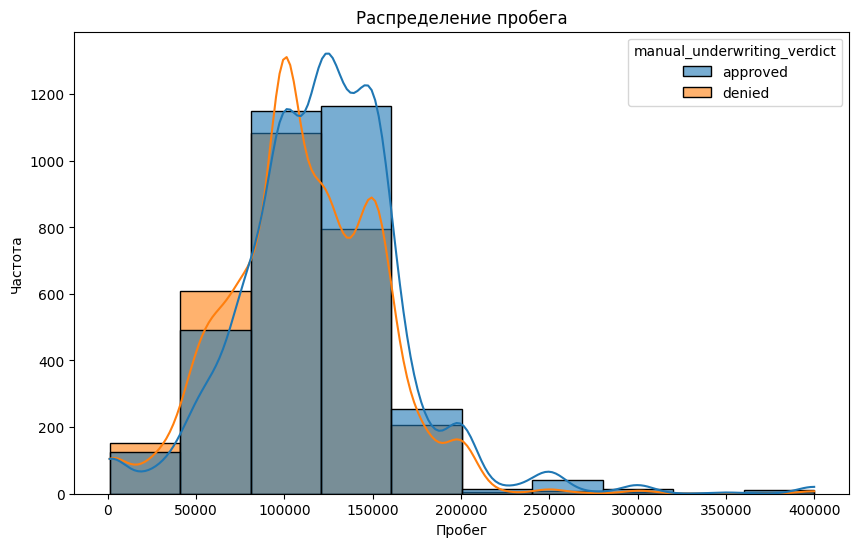

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='mileage',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение пробега')
plt.xlabel('Пробег')
plt.ylabel('Частота')
plt.show()

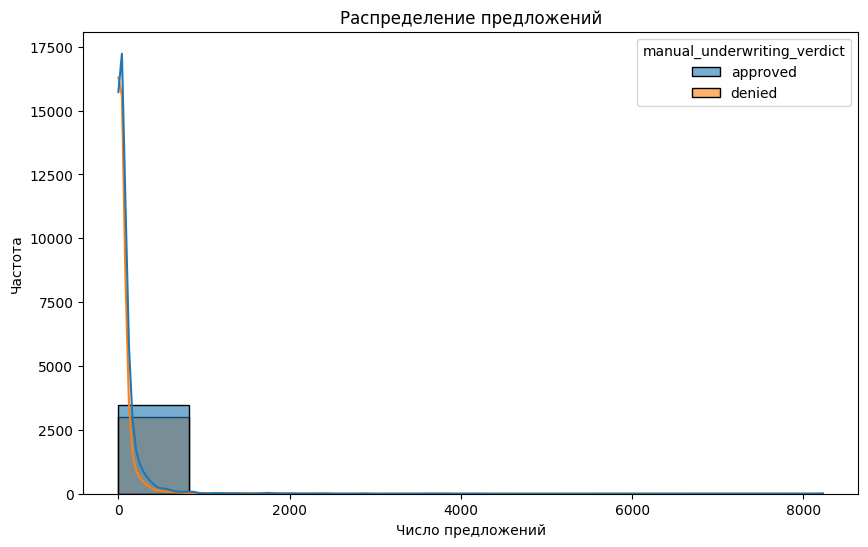

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='offers_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение предложений')
plt.xlabel('Число предложений')
plt.ylabel('Частота')
plt.show()

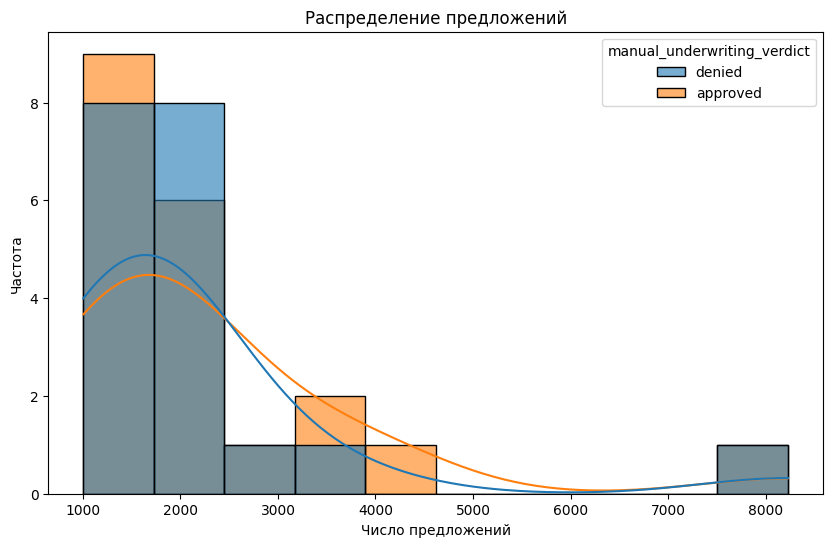

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified[car_data_modified['offers_count'] > 1000],
    x='offers_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение предложений')
plt.xlabel('Число предложений')
plt.ylabel('Частота')
plt.show()

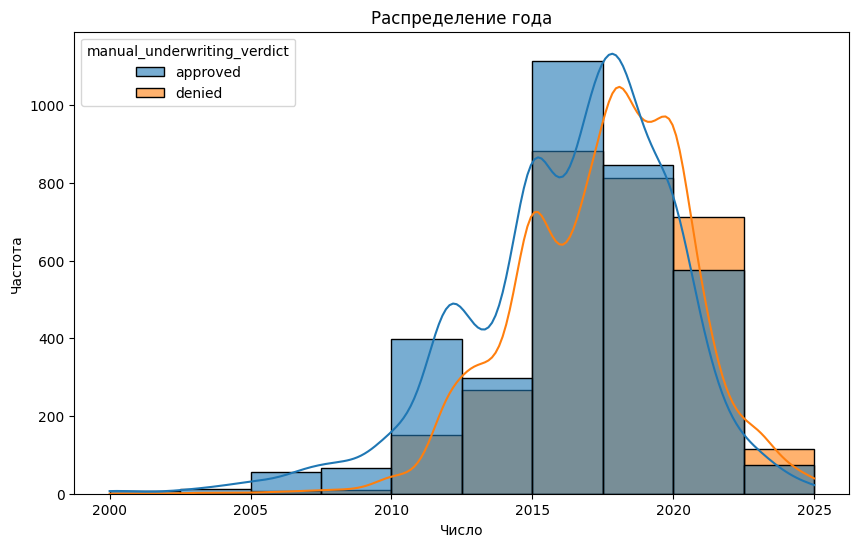

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='year',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение года')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

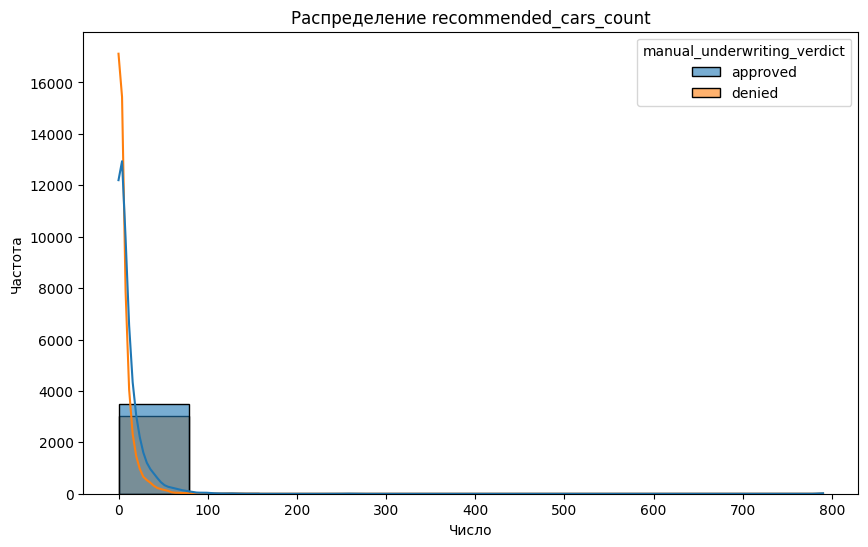

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='recommended_cars_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение recommended_cars_count')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

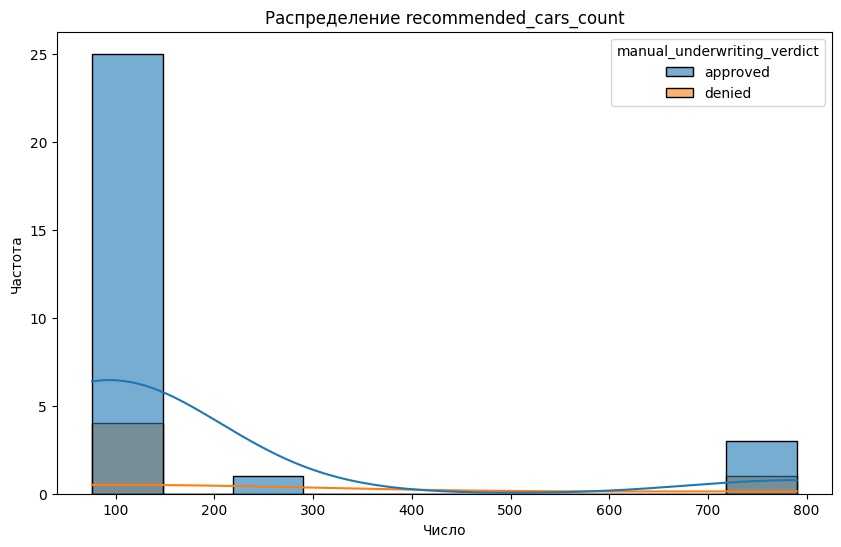

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified[car_data_modified['recommended_cars_count'] > 75],
    x='recommended_cars_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение recommended_cars_count')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

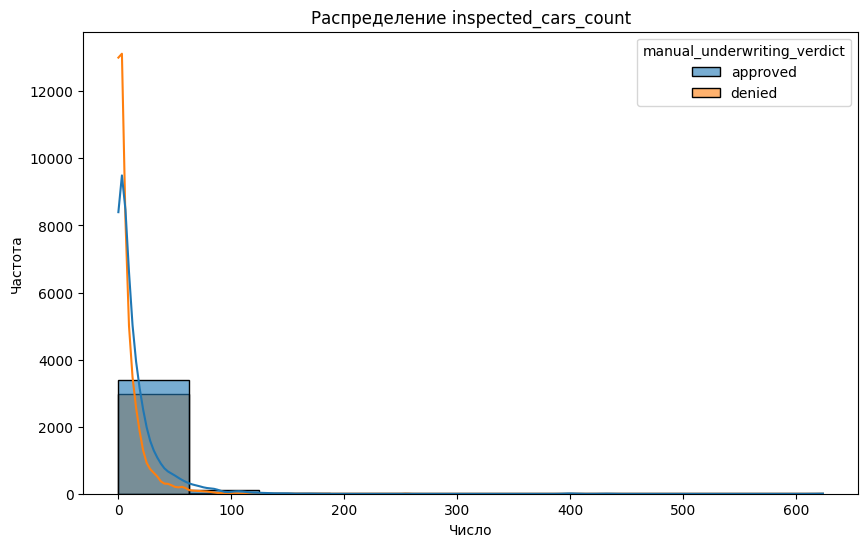

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='inspected_cars_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение inspected_cars_count')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

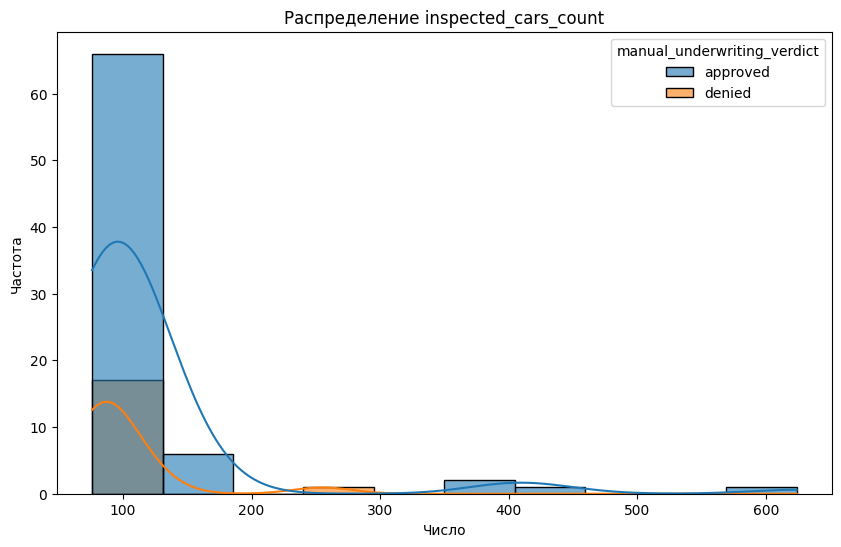

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified[car_data_modified['inspected_cars_count'] > 75],
    x='inspected_cars_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение inspected_cars_count')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

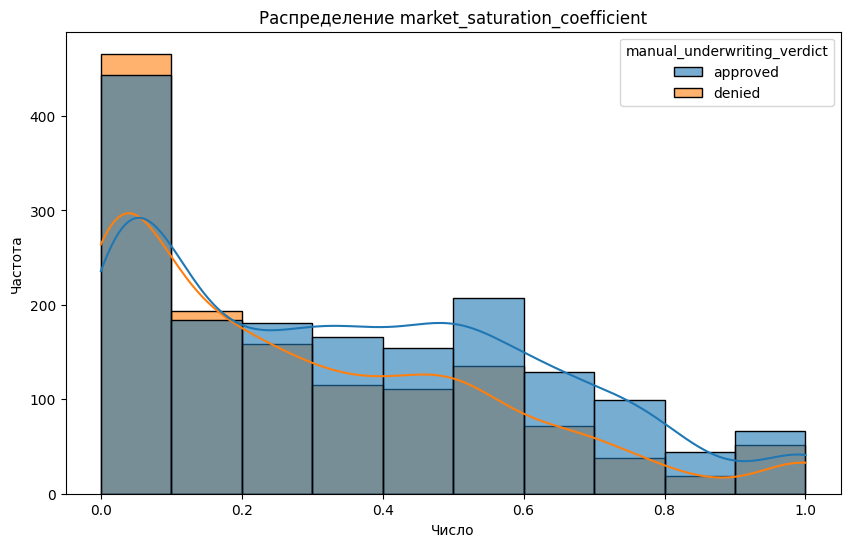

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='market_saturation_coefficient',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение market_saturation_coefficient')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

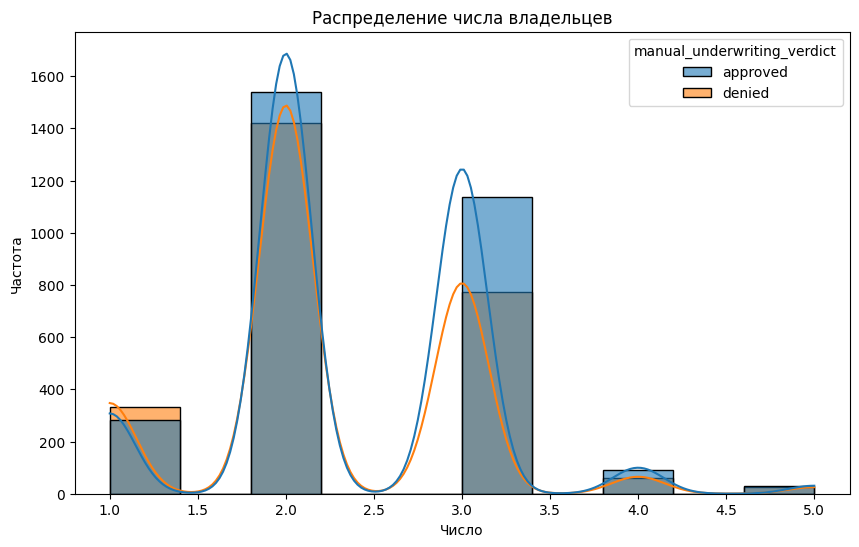

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='max_owners',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение числа владельцев')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

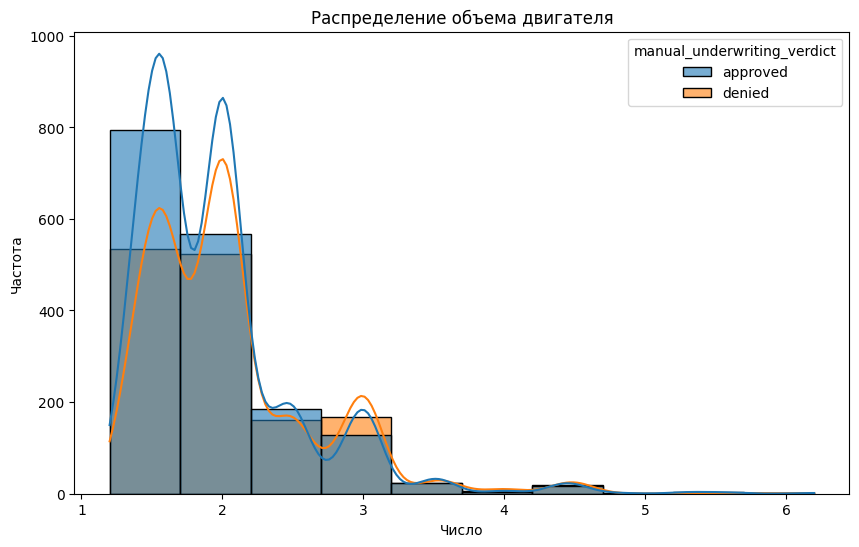

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=car_data_modified,
    x='min_volume',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение объема двигателя')
plt.xlabel('Число')
plt.ylabel('Частота')
plt.show()

## Загрузка информации из БД

Парсинг сайтов не приводиться по просьбе заказчика

In [ ]:
print(car_data['ads_query_debug'][4000])

In [ ]:
car_data_modified[car_data_modified['index'] == 4000]

In [47]:
# conn.close()

### Сохранение новых и обработанных данных

In [48]:
# with open('car_data_modified.pkl', 'wb') as f:
#     pickle.dump(car_data_modified, f)

## Фильтрация объявлений

In [49]:
# with open('car_data_modified.pkl', 'rb') as f:
#     car_data_modified = pickle.load(f)

In [50]:
car_data_modified = car_data_modified.dropna(subset=['ads_data'])

In [51]:
car_data_modified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1452 entries, 5068 to 6519
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   level_0                        1452 non-null   int64  
 1   index                          1452 non-null   int64  
 2   desired_criteria               1452 non-null   object 
 3   service_change                 1452 non-null   int64  
 4   matched_orders_count           1452 non-null   int64  
 5   inspected_cars_count           1452 non-null   int64  
 6   recommended_cars_count         1452 non-null   int64  
 7   offers_count                   1452 non-null   int64  
 8   ads_market_count               1452 non-null   float64
 9   market_saturation_coefficient  1405 non-null   float64
 10  region                         1452 non-null   object 
 11  ads_data                       1452 non-null   object 
 12  manual_underwriting_verdict    1452 non-null   obj

In [52]:
def filter_ads_data(criteria, ads_data):
    criteries = parse_criteria(criteria)
    filtered = []
    global mistakes
    for ad in ads_data:
        try:
            if criteries['year'] == criteries['year']:
                if ad['year'] < criteries['year']:
#                     print('year', ad['year'], '| критерий:', criteries['year'])
                    continue
            if ad['km_age'] is not None:
                if ad['km_age'] > criteries['mileage'] + 1000:
#                     print('km_age', ad['km_age'], '| критерий:', criteries['mileage'])
                    continue
            if float(ad['price']) > criteries['budget']:
#                 print('price', ad['price'], '| критерий:', criteries['budget'])
                continue
            if criteries['max_owners'] == criteries['max_owners']:
                if ad['owners_count'] == '4+':
                    if criteries['max_owners'] < 4:
#                         print('owners', ad['owners_count'], '| критерий:', criteries['max_owners'])
                        continue
                elif ad['owners_count'] != None:
                    if int(ad['owners_count']) > criteries['max_owners']:
#                         print('owners', ad['owners_count'], '| критерий:', criteries['max_owners'])
                        continue
#             if ad['generation_id'] != criteries['generation']:
#                 continue
            if criteries['max_volume'] == criteries['max_volume']:
                if not (criteries['min_volume'] <= float(ad['displacement']) <= criteries['max_volume']):
#                     print('volume', ad['displacement'], '| критерий:', criteries['min_volume'], criteries['max_volume'])
                    continue
            if criteries['trasmission'] != 'Любая':
                transmission = dict_transmission[dict_transmission['id'] == int(ad['transmission_type_id'])]
                transmission = transmission['label'].item()
                if transmission != criteries['trasmission']:
                    if transmission not in criteries['trasmission'].split(', '):
#                         print('transmission', transmission, '| критерий:', criteries['trasmission'])
                        continue
            if criteries['engine_type'] != 'Любой':
                engine = dict_engine_type[dict_engine_type['id'] == int(ad['engine_type_id'])]
                engine = engine['label'].item()
                if engine != criteries['engine_type']:
                    if engine not in criteries['engine_type'].split(', '):
#                         print('engine', engine, '| критерий:', criteries['engine_type'])
                        continue
            if criteries['body_type'] != 'Любой':
                body = dict_body[dict_body['id'] == int(ad['body_type_id'])]
                body = body['label'].item()
                if body != criteries['body_type']:
                    if body not in criteries['body_type'].split(', '):
#                         print('body', body, '| критерий:', criteries['body_type'])
                        continue 
            if criteries['wheel_drive'] != 'Любой':
                wheel = dict_drive_type[dict_drive_type['id'] == int(ad['drive_type_id'])]
                wheel = wheel['label'].item()
                if wheel != criteries['wheel_drive']:
                    if wheel not in criteries['wheel_drive'].split(', '):
#                         print('wheel', wheel, '| критерий:', criteries['wheel_drive'])
                        continue
            if criteries['color'] != 'Любой':
                color = dict_color[dict_color['id'] == int(ad['color_id'])]
                color = color['label'].item()
                if color != criteries['color']:
                    if color not in criteries['color'].split(', '):
#                         print('color', color, '| критерий:', criteries['color'])
                        continue
            filtered.append(ad)
        except TypeError as e:
            print(f"Ошибка с элементом {ad}: {e}. Пропускаем...")
            mistakes += 1
            continue
    return filtered

In [53]:
def filter_ads_data_logs(criteria, ads_data):
    criteries = parse_criteria(criteria)
    filtered = []
    global mistakes
    for ad in ads_data:
        try:
            if criteries['year'] == criteries['year']:
                if ad['year'] < criteries['year']:
                    print('year', ad['year'], '| критерий:', criteries['year'])
                    continue
            if ad['km_age'] is not None:
                if ad['km_age'] > criteries['mileage'] + 1000:
                    print('km_age', ad['km_age'], '| критерий:', criteries['mileage'])
                    continue
            if float(ad['price']) > criteries['budget']:
                print('price', ad['price'], '| критерий:', criteries['budget'])
                continue
            if criteries['max_owners'] == criteries['max_owners']:
                if ad['owners_count'] == '4+':
                    if criteries['max_owners'] < 4:
                        print('owners', ad['owners_count'], '| критерий:', criteries['max_owners'])
                        continue
                elif ad['owners_count'] != None:
                    if int(ad['owners_count']) > criteries['max_owners']:
                        print('owners', ad['owners_count'], '| критерий:', criteries['max_owners'])
                        continue
#             if ad['generation_id'] != criteries['generation']:
#                 continue
            if criteries['max_volume'] == criteries['max_volume']:
                if not (criteries['min_volume'] <= float(ad['displacement']) <= criteries['max_volume']):
                    print('volume', ad['displacement'], '| критерий:', criteries['min_volume'], criteries['max_volume'])
                    continue
            if criteries['trasmission'] != 'Любая':
                transmission = dict_transmission[dict_transmission['id'] == int(ad['transmission_type_id'])]
                transmission = transmission['label'].item()
                if transmission != criteries['trasmission']:
                    if transmission not in criteries['trasmission'].split(', '):
                        print('transmission', transmission, '| критерий:', criteries['trasmission'])
                        continue
            if criteries['engine_type'] != 'Любой':
                engine = dict_engine_type[dict_engine_type['id'] == int(ad['engine_type_id'])]
                engine = engine['label'].item()
                if engine != criteries['engine_type']:
                    if engine not in criteries['engine_type'].split(', '):
                        print('engine', engine, '| критерий:', criteries['engine_type'])
                        continue
            if criteries['body_type'] != 'Любой':
                body = dict_body[dict_body['id'] == int(ad['body_type_id'])]
                body = body['label'].item()
                if body != criteries['body_type']:
                    if body not in criteries['body_type'].split(', '):
                        print('body', body, '| критерий:', criteries['body_type'])
                        continue 
            if criteries['wheel_drive'] != 'Любой':
                wheel = dict_drive_type[dict_drive_type['id'] == int(ad['drive_type_id'])]
                wheel = wheel['label'].item()
                if wheel != criteries['wheel_drive']:
                    if wheel not in criteries['wheel_drive'].split(', '):
                        print('wheel', wheel, '| критерий:', criteries['wheel_drive'])
                        continue
            if criteries['color'] != 'Любой':
                color = dict_color[dict_color['id'] == int(ad['color_id'])]
                color = color['label'].item()
                if color != criteries['color']:
                    if color not in criteries['color'].split(', '):
                        print('color', color, '| критерий:', criteries['color'])
                        continue
            filtered.append(ad)
        except TypeError as e:
            print(f"Ошибка с элементом {ad}: {e}. Пропускаем...")
            mistakes += 1
            continue
    print(len(ads_data), len(filtered))
    return filtered

In [109]:
# ручной тест объявлений
# i = 0
# filter_ads_data_logs(car_data_modified['desired_criteria'][i], car_data_modified['ads_data'][i])

In [ ]:
mistakes = 0
car_data_modified['ads_data'] = car_data_modified.apply(lambda row:
                                                  filter_ads_data(row['desired_criteria'], row['ads_data']), axis=1)
print('Всего ошибок: ', mistakes)

In [58]:
mistakes = 0
def parse_ads(data):
    global mistakes
    try:
        if len(data) == 0:
            ads_info = {
            'median_year': np.nan,
            'median_km_age': np.nan,
            'median_price': np.nan,
            'median_owners': np.nan
            }
        else: 
            search_data = pd.DataFrame(data)
            search_data['price'] = pd.to_numeric(search_data['price'], errors='coerce')
            search_data['owners_count'] = pd.to_numeric(search_data['owners_count'], errors='coerce')
            ads_description = search_data.describe()
            ads_info = {
                'median_year': float(ads_description['year']['50%']),
                'median_km_age': float(ads_description['km_age']['50%']),
                'median_price': float(ads_description['price']['50%']),
                'median_owners': float(ads_description['owners_count']['50%']),
            }    
        
    except:
        mistakes += 1
        ads_info = {
            'median_year': np.nan,
            'median_km_age': np.nan,
            'median_price': np.nan,
            'median_owners': np.nan
            }
    return pd.Series(ads_info)
# parse_ads(car_data_modified['ads_data'][0]).index

In [ ]:
car_data_modified[['median_year',
                'median_km_age', 
                'median_price', 
                'median_owners']] = car_data_modified['ads_data'].apply(parse_ads)
car_data_modified['ads_count'] = car_data_modified['ads_data'].apply(len)
print("Ошибок: ", mistakes)
car_data_modified.head(2)

In [60]:
car_data_modified.columns

Index(['level_0', 'index', 'desired_criteria', 'service_change',
       'matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'offers_count', 'ads_market_count',
       'market_saturation_coefficient', 'region', 'ads_data',
       'manual_underwriting_verdict', 'brand', 'model', 'year', 'generation',
       'mileage', 'budget', 'max_owners', 'min_volume', 'max_volume',
       'trasmission', 'engine_type', 'body_type', 'wheel_drive', 'color',
       'complectation', 'comment', 'median_year', 'median_km_age',
       'median_price', 'median_owners', 'ads_count'],
      dtype='object')

In [ ]:
car_data_modified.describe()

## Замена параметров в объявлениях по словарям

In [63]:
# car_data_modified['ads_data'][0][0]

In [64]:
def change_ads(ads):
    new_ads = []
    keys_to_del = ['id', 'listing_id', 'listing_inner_id',
                   'url', 'seller_url', 'seller_id', 'address',
                   'offer_created', 'date_created',
                   'date_updated', 'location_city_id', 'location_region_id',
                   'mark_id', 'model_id', 'custom_status_id', 'sys_props']
    for ad in ads:
        for key in keys_to_del:
            try: 
                del ad[key]
            except KeyError:
                pass
        try:
            # заменяем кузов  
            if ad['body_type_id'] == None:
                ad['body_type'] = None
            else:
                ad['body_type'] = dict_body[dict_body['id'] == int(ad['body_type_id'])]['label'].item()
            del ad['body_type_id']
        except KeyError:
            pass
        try:
            # заменяем цвет  
            if ad['color_id'] == None:
                ad['color'] = None
            else:       
                ad['color'] = dict_color[dict_color['id'] == int(ad['color_id'])]['label'].item()
            del ad['color_id']
        except KeyError:
            pass
        try:
            # заменяем состояние авто  
            if ad['condition_status_id'] == None:
                ad['condition_status'] = None
            else:       
                ad['condition_status'] = dict_condition[dict_condition['id'] == int(ad['condition_status_id'])]['label'].item()
            del ad['condition_status_id']
        except KeyError:
            pass
        try:
            # заменяем тип привода  
            if ad['drive_type_id'] == None:
                ad['drive_type'] = None
            else:       
                ad['drive_type'] = dict_drive_type[dict_drive_type['id'] == int(ad['drive_type_id'])]['label'].item()
            del ad['drive_type_id']
        except KeyError:
            pass
        try:
            # заменяем тип двигателя  
            if ad['engine_type_id'] == None:
                ad['engine_type'] = None
            else:       
                ad['engine_type'] = dict_engine_type[dict_engine_type['id'] == int(ad['engine_type_id'])]['label'].item()
            del ad['engine_type_id']
        except KeyError:
            pass
        try:
            # заменяем поколение
            if ad['generation_id'] == None:
                ad['generation'] = None
            else:       
                ad['generation'] = dict_generation[dict_generation['id'] == int(ad['generation_id'])]['label'].item()
            del ad['generation_id']
        except KeyError:
            pass
        try:
            # заменяем источник
            if ad['source_id'] == None:
                ad['source'] = None
            else:       
                ad['source'] = dict_source[dict_source['id'] == int(ad['source_id'])]['label'].item()
            del ad['source_id']
        except KeyError:
            pass
        try:
            # заменяем трансмиссию
            if ad['transmission_type_id'] == None:
                ad['transmission_type'] = None
            else:       
                ad['transmission_type'] = dict_transmission[dict_transmission['id'] == int(ad['transmission_type_id'])]['label'].item()
            del ad['transmission_type_id']
        except KeyError:
            pass
        try:
            # заменяем привод
            if ad['wheel_type_id'] == None:
                ad['wheel_type'] = None
            else:       
                ad['wheel_type'] = dict_wheel_type[dict_wheel_type['id'] == int(ad['wheel_type_id'])]['label'].item()
            del ad['wheel_type_id']
        except KeyError:
            pass
        new_ads.append(ad)
    return new_ads

In [65]:
car_data_modified['ads_data'] = car_data_modified['ads_data'].apply(change_ads)

In [66]:
car_data_modified.columns

Index(['level_0', 'index', 'desired_criteria', 'service_change',
       'matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'offers_count', 'ads_market_count',
       'market_saturation_coefficient', 'region', 'ads_data',
       'manual_underwriting_verdict', 'brand', 'model', 'year', 'generation',
       'mileage', 'budget', 'max_owners', 'min_volume', 'max_volume',
       'trasmission', 'engine_type', 'body_type', 'wheel_drive', 'color',
       'complectation', 'comment', 'median_year', 'median_km_age',
       'median_price', 'median_owners', 'ads_count'],
      dtype='object')

In [67]:
cleared_data = car_data_modified[['service_change', 'matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count',
       'market_saturation_coefficient', 'region', 
       'manual_underwriting_verdict', 'brand', 'model', 'year', 'generation',
       'mileage', 'budget', 'max_owners', 'median_year',
       'median_km_age', 'median_price', 'median_owners', 'ads_count']]

In [68]:
cleared_data = cleared_data.dropna(subset='manual_underwriting_verdict')
cleared_data['manual_underwriting_verdict'] = cleared_data['manual_underwriting_verdict']\
                                              .apply(lambda x: 0 if x == 'denied' else 1)

In [69]:
cleared_data['manual_underwriting_verdict'].unique()

array([1, 0])

In [ ]:
cleared_data.describe()

## Изменение колонок

In [211]:
cleared_data.columns

Index(['service_change', 'matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'market_saturation_coefficient', 'region',
       'manual_underwriting_verdict', 'brand', 'model', 'year', 'generation',
       'mileage', 'budget', 'max_owners', 'median_year', 'median_km_age',
       'median_price', 'median_owners', 'ads_count'],
      dtype='object')

In [302]:
changed_data = cleared_data[['matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'market_saturation_coefficient', 'region', 
       'manual_underwriting_verdict', 'brand', 'year', 'generation',
       'mileage', 'budget', 'max_owners',
       'ads_count']]
changed_data['generation'] = cleared_data['model'] + " " + changed_data['generation']
changed_data['median_year'] = cleared_data['year'] - cleared_data['median_year']
changed_data['median_price'] = cleared_data['budget'] - cleared_data['median_price']
changed_data['median_km_age'] = cleared_data['mileage'] - cleared_data['median_km_age']
changed_data['median_owners'] = cleared_data['max_owners'] - cleared_data['median_owners']
changed_data['good_ads_prob_count'] = (changed_data['recommended_cars_count'] / 
                                       changed_data['inspected_cars_count'] *
                                       changed_data['ads_count'])
changed_data['year'] = changed_data['year'].astype('Int64').astype(str)

C:\Users\paulv\AppData\Local\Temp\ipykernel_60340\841597552.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  changed_data['generation'] = cleared_data['model'] + " " + changed_data['generation']
C:\Users\paulv\AppData\Local\Temp\ipykernel_60340\841597552.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  changed_data['median_year'] = cleared_data['year'] - cleared_data['median_year']
C:\Users\paulv\AppData\Local\Temp\ipykernel_60340\841597552.py:8: SettingWithCopyWarning: 
A value is trying to be set on

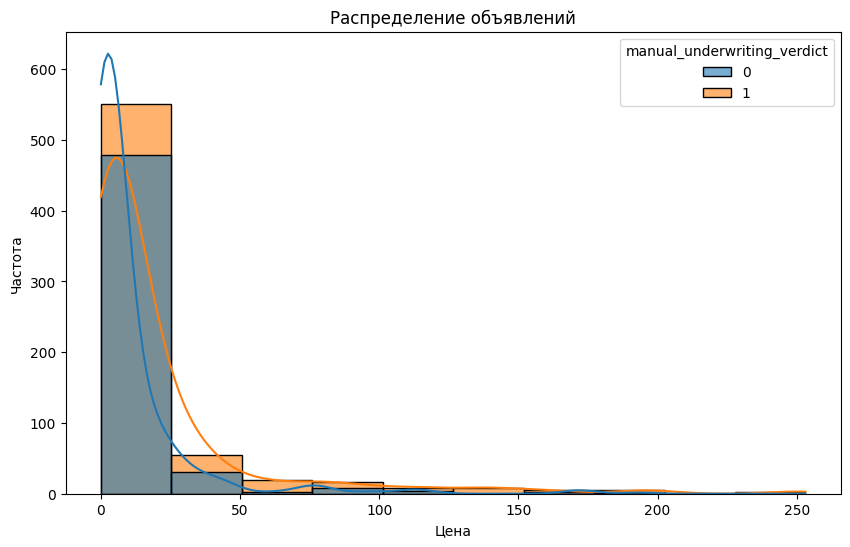

In [303]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=changed_data,
    x='good_ads_prob_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение объявлений')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

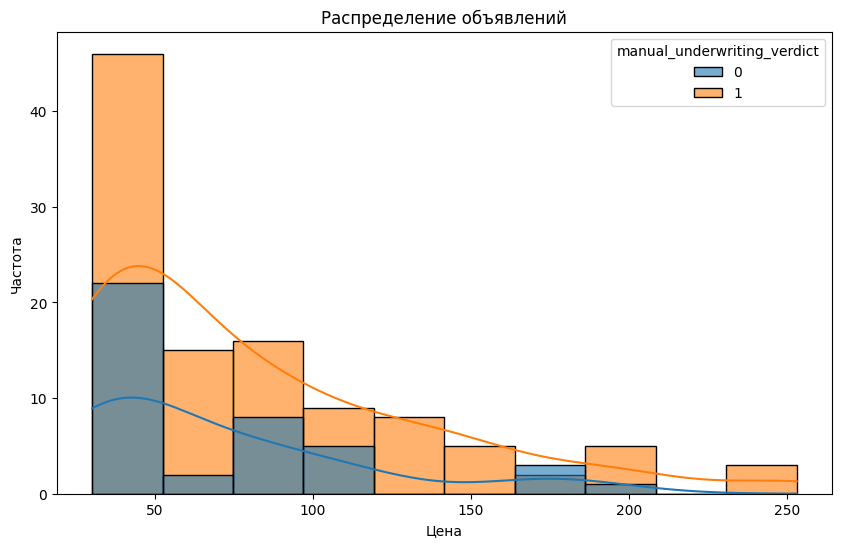

In [304]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=changed_data[changed_data['good_ads_prob_count'] > 30],
    x='good_ads_prob_count',
    hue='manual_underwriting_verdict',
    alpha=0.6,
    bins=10,
    kde=True,
)
plt.title('Распределение объявлений')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

In [ ]:
changed_data.head(3)

In [306]:
changed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1452 entries, 5068 to 6519
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   matched_orders_count           1452 non-null   int64  
 1   inspected_cars_count           1452 non-null   int64  
 2   recommended_cars_count         1452 non-null   int64  
 3   market_saturation_coefficient  1405 non-null   float64
 4   region                         1452 non-null   object 
 5   manual_underwriting_verdict    1452 non-null   int64  
 6   brand                          1452 non-null   object 
 7   year                           1452 non-null   object 
 8   generation                     1452 non-null   object 
 9   mileage                        1372 non-null   float64
 10  budget                         1451 non-null   float64
 11  max_owners                     1256 non-null   float64
 12  ads_count                      1452 non-null   int

In [ ]:
changed_data.describe()

In [308]:
# changed_data.replace([np.inf, -np.inf], np.nan, inplace=True)
# changed_data.dropna(inplace=True)

In [ ]:
X = changed_data.drop(columns = ['manual_underwriting_verdict'])
y = changed_data['manual_underwriting_verdict']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, 
                                                    random_state=RANDOM_STATE)
X.head(3)

In [310]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1452 entries, 5068 to 6519
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   matched_orders_count           1452 non-null   int64  
 1   inspected_cars_count           1452 non-null   int64  
 2   recommended_cars_count         1452 non-null   int64  
 3   market_saturation_coefficient  1405 non-null   float64
 4   region                         1452 non-null   object 
 5   brand                          1452 non-null   object 
 6   year                           1452 non-null   object 
 7   generation                     1452 non-null   object 
 8   mileage                        1372 non-null   float64
 9   budget                         1451 non-null   float64
 10  max_owners                     1256 non-null   float64
 11  ads_count                      1452 non-null   int64  
 12  median_year                    1223 non-null   flo

In [311]:
X.select_dtypes(include=['int64', 'float64']).columns.tolist()

['matched_orders_count',
 'inspected_cars_count',
 'recommended_cars_count',
 'market_saturation_coefficient',
 'mileage',
 'budget',
 'max_owners',
 'ads_count',
 'median_year',
 'median_price',
 'median_km_age',
 'median_owners',
 'good_ads_prob_count']

In [312]:
ohe_columns = [
    'region',
    'brand',
    # 'model',
    'year',
    'generation',
#     'engine_type',
#     'body_type',
#     'wheel_drive'    
] 

ord_columns = []
ord_columns_order = []

num_columns = ['matched_orders_count',
             'inspected_cars_count',
             'recommended_cars_count',
             'offers_count',
             'ads_market_count',
             'year',
             'min_year',
             'max_year',
             'median_year',
             'min_price',
             'max_price',
             'median_price',
             'min_km_age',
             'max_km_age',
             'median_km_age',
             'min_owners',
             'max_owners_ad',
             'median_owners']
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values='Unknown', strategy='constant', fill_value='Unknown')
        ),
#         (
#             'ohe', 
#             OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
#         )
    ]
) 
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan,
            categories=ord_columns_order
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 
data_preprocessor = ColumnTransformer(
    [
        #('ohe', ohe_pipe, ohe_columns),
        #('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
) 

## Построение модели LGBMClassifier

In [ ]:
X_lgb = X.copy(deep=True)
X_lgb[ohe_columns] = X_lgb[ohe_columns].astype('category')
X_lgb.head(3)

In [314]:
X_train_lgb, X_test_lgb, y_train, y_test = train_test_split(X_lgb, y, test_size=0.25, stratify=y,
                                                    random_state=RANDOM_STATE)

In [315]:
X_lgb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1452 entries, 5068 to 6519
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   matched_orders_count           1452 non-null   int64   
 1   inspected_cars_count           1452 non-null   int64   
 2   recommended_cars_count         1452 non-null   int64   
 3   market_saturation_coefficient  1405 non-null   float64 
 4   region                         1452 non-null   category
 5   brand                          1452 non-null   category
 6   year                           1452 non-null   category
 7   generation                     1452 non-null   category
 8   mileage                        1372 non-null   float64 
 9   budget                         1451 non-null   float64 
 10  max_owners                     1256 non-null   float64 
 11  ads_count                      1452 non-null   int64   
 12  median_year                    1223 

In [316]:
lgbm = lgb.LGBMClassifier(num_leaves=4, n_estimators=1000, metric=["l1", "l2"], max_depth=4,
                          random_state=RANDOM_STATE)
cv_score_lgbm = cross_val_score(lgbm, X_train_lgb, y_train, cv=5, n_jobs=-1, scoring='roc_auc')
print(f'{np.mean(cv_score_lgbm):.3f}')

0.646


In [317]:
pipe = Pipeline(
    [
        #('preprocessor', data_preprocessor),
        ('models', lgb.LGBMClassifier(num_leaves=4, n_estimators=1000, metric=["l1", "l2"], max_depth=4,
                          random_state=RANDOM_STATE))
    ]
) 

In [318]:
param_grid = [{
        'models': [lgb.LGBMClassifier(random_state=RANDOM_STATE)],
        'models__num_leaves': [5, 10, 50, 100],
        'models__num_boost_round': [1000],
        'models__n_estimators': [1000],
        'models__max_depth': [4, 20] 
    }
] 

In [319]:
search = GridSearchCV(
    pipe, 
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)
grid_search_lgb = search.fit(X_train_lgb, y_train)
result = pd.DataFrame(grid_search_lgb.cv_results_)
print(result.columns)
output_result = result[['mean_fit_time', 'mean_test_score', 'mean_score_time', 'param_models']].sort_values('mean_test_score', ascending=False)
output_result.head(5)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Warning] num_iterations is set=1000, num_boost_round=1000 will be ignored. Current value: num_iterations=1000
[LightGBM] [Info] Number of positive: 590, number of negative: 499
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 1089, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.541781 -> initscore=0.167516
[LightGBM] [Info] Start training from score 0.167516
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

,mean_fit_time,mean_test_score,mean_score_time,param_models
6,7.852300,0.665809,0.014172,LGBMClassifier(random_state=1)
7,6.882235,0.665809,0.017969,LGBMClassifier(random_state=1)
5,4.424765,0.657073,0.014976,LGBMClassifier(random_state=1)
3,5.144066,0.651204,0.015499,LGBMClassifier(random_state=1)
2,5.173369,0.651204,0.013583,LGBMClassifier(random_state=1)


In [320]:
grid_search_lgb

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'models': [LGBMClassifier(random_state=1)], 'models__max_depth': [4, 20], 'models__n_estimators': [1000], 'models__num_boost_round': [1000], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [321]:
y_pred_lgbm = grid_search_lgb.predict_proba(X_test_lgb)
lgbm_score = roc_auc_score(y_test, y_pred_lgbm[:, 1])
print(f'{lgbm_score:.4f}')

0.6886


In [322]:
best_lgb = grid_search_lgb.best_estimator_.named_steps['models']
best_lgb

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,20
,learning_rate,0.1
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


C:\Users\paulv\.conda\envs\underwriting\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


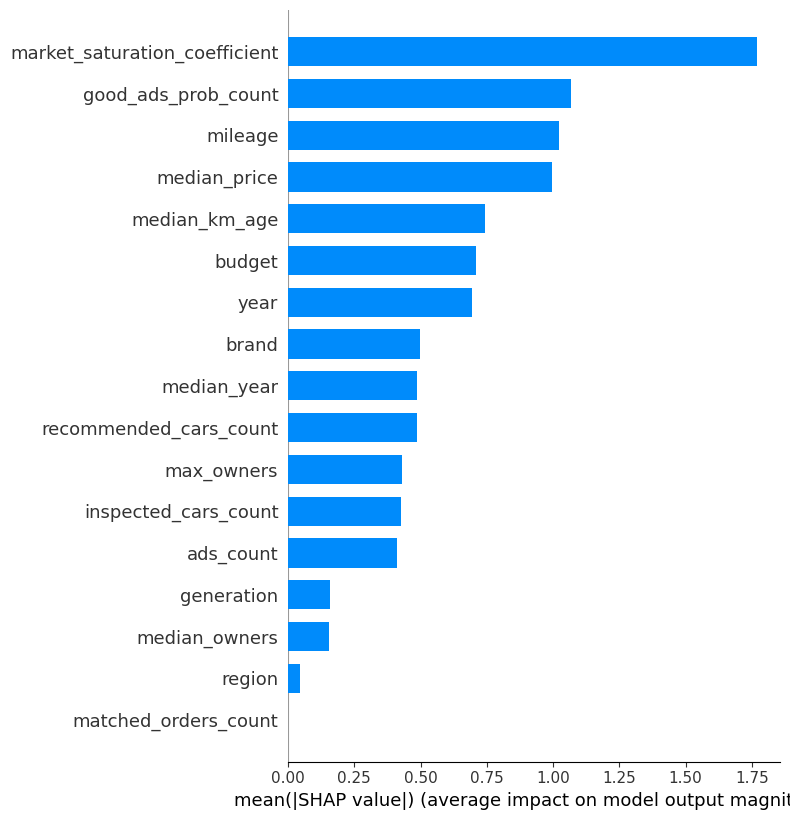

In [323]:
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test_lgb)
shap.summary_plot(shap_values, X_test_lgb, plot_type="bar")
plt.show()

## Построение модели XGBoost

In [324]:
X_xg = X.copy(deep=True)
X_xg[ohe_columns] = X_xg[ohe_columns].astype('category')
X_train_xg, X_test_xg, y_train, y_test = train_test_split(X_xg, y, test_size=0.25, stratify=y,
                                                    random_state=RANDOM_STATE)
X_xg.head(2)

,matched_orders_count,inspected_cars_count,recommended_cars_count,market_saturation_coefficient,region,brand,year,generation,mileage,budget,max_owners,ads_count,median_year,median_price,median_km_age,median_owners,good_ads_prob_count
5068,0,105,79,0.4796,msk,Skoda,2017,Rapid Поколение I Рестайлинг,130000.0,1500000.0,2.0,43,-4.0,70000.0,29500.0,0.0,32.352381
5069,0,0,0,0.1290,msk,Volvo,2018,XC90 Поколение II,100000.0,4000000.0,2.0,0,NaN,NaN,NaN,NaN,NaN


In [325]:
X_xg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1452 entries, 5068 to 6519
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   matched_orders_count           1452 non-null   int64   
 1   inspected_cars_count           1452 non-null   int64   
 2   recommended_cars_count         1452 non-null   int64   
 3   market_saturation_coefficient  1405 non-null   float64 
 4   region                         1452 non-null   category
 5   brand                          1452 non-null   category
 6   year                           1452 non-null   category
 7   generation                     1452 non-null   category
 8   mileage                        1372 non-null   float64 
 9   budget                         1451 non-null   float64 
 10  max_owners                     1256 non-null   float64 
 11  ads_count                      1452 non-null   int64   
 12  median_year                    1223 

In [326]:
dtrain = xgb.DMatrix(X_train_xg, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test_xg, label=y_test, enable_categorical=True)

In [327]:
params = {
    'objective': 'binary:logistic',      # для бинарной классификации
    'eval_metric': 'auc',        # метрика для валидации
    'max_depth': 4,                 # глубина деревьев
    'learning_rate': 0.1,         # скорость обучения
    'subsample': 0.8,             # доля объектов для обучения
    'colsample_bytree': 0.8,     # доля признаков для каждого дерева
    'gamma': 1,                   # минимальный убыток для разделения
    'reg_lambda': 1,            # L2‑регуляризация
    'seed': RANDOM_STATE
}

In [328]:
num_round = 100
model = xgb.train(
    params,
    dtrain,
    num_round,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds=10,   # остановка при отсутствии улучшения
    verbose_eval=False
)

In [329]:
y_preds_xg = model.predict(dtest)
xg_score = roc_auc_score(y_test, y_preds_xg)
print(f'{xg_score:.3f}')

0.720


In [330]:
pipe = Pipeline(
    [
        #('preprocessor', data_preprocessor),
        ('models', xgb.XGBClassifier(objective = 'binary:logistic', eval_metric='auc', enable_categorical=True, 
                          random_state=RANDOM_STATE))
    ]
) 

In [387]:
param_grid = [{
        'models': [xgb.XGBClassifier(objective = 'binary:logistic', eval_metric='auc', enable_categorical=True, 
                          random_state=RANDOM_STATE)],
        'models__max_depth': [3, 5, 10],
        'models__learning_rate': [0.05, 0.1, 0.3],
        'models__gamma': [3, 7, 10],
        'models__colsample_bytree': [0.2, 0.4, 0.6],
        'models__min_child_weight': [3, 5, 7],
        'models__booster': ['gbtree', 'dart'],
    }
] 

In [388]:
search = GridSearchCV(
    pipe, 
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)
grid_search_xg = search.fit(X_train_xg, y_train)
result = pd.DataFrame(grid_search_xg.cv_results_)
print(result.columns)
output_result = result[['mean_fit_time', 'mean_test_score', 'mean_score_time', 'param_models']].sort_values('mean_test_score', ascending=False)
output_result.head(5)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_models', 'param_models__booster',
       'param_models__colsample_bytree', 'param_models__gamma',
       'param_models__learning_rate', 'param_models__max_depth',
       'param_models__min_child_weight', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score'],
      dtype='object')


,mean_fit_time,mean_test_score,mean_score_time,param_models
82,0.083913,0.698249,0.016215,"XGBClassifier(base_score=None, booster=None, c..."
325,4.208436,0.697808,0.045327,"XGBClassifier(base_score=None, booster=None, c..."
334,4.211923,0.697693,0.048497,"XGBClassifier(base_score=None, booster=None, c..."
22,0.054365,0.697670,0.015707,"XGBClassifier(base_score=None, booster=None, c..."
6,0.064984,0.697307,0.014445,"XGBClassifier(base_score=None, booster=None, c..."


In [389]:
grid_search_xg

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'models': [XGBClassifier...ree=None, ...)], 'models__booster': ['gbtree', 'dart'], 'models__colsample_bytree': [0.2, 0.4, ...], 'models__gamma': [3, 7, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [390]:
y_pred_xg = grid_search_xg.predict_proba(X_test_xg)
xg_score = roc_auc_score(y_test, y_pred_xg[:, 1])
print(f'{xg_score:.4f}')

0.7285


In [371]:
print(f'lgbm_score:{lgbm_score:.4f}')
print(f'xg_score:{xg_score:.4f}')

lgbm_score:0.6886
xg_score:0.7285


In [398]:
X_test_xg['xg_verdict'] = grid_search_xg.predict(X_test_xg)

In [399]:
X_test_xg['manual_verdict'] = y_test

In [400]:
X_test_xg.columns

Index(['matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'market_saturation_coefficient', 'region',
       'brand', 'year', 'generation', 'mileage', 'budget', 'max_owners',
       'ads_count', 'median_year', 'median_price', 'median_km_age',
       'median_owners', 'good_ads_prob_count', 'xg_verdict', 'manual_verdict'],
      dtype='object')

In [ ]:
test = X_test_xg[['matched_orders_count', 'inspected_cars_count',
       'recommended_cars_count', 'market_saturation_coefficient', 'region',
       'brand', 'year', 'generation', 'mileage', 'budget', 'max_owners',
       'ads_count', 'median_year', 'median_price', 'median_km_age',
       'median_owners', 'good_ads_prob_count', 'xg_verdict', 'manual_verdict']]
test[test['brand'] == 'Skoda'].head(5)

In [402]:
best_xg = grid_search_xg.best_estimator_.named_steps['models']
best_xg

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.4
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

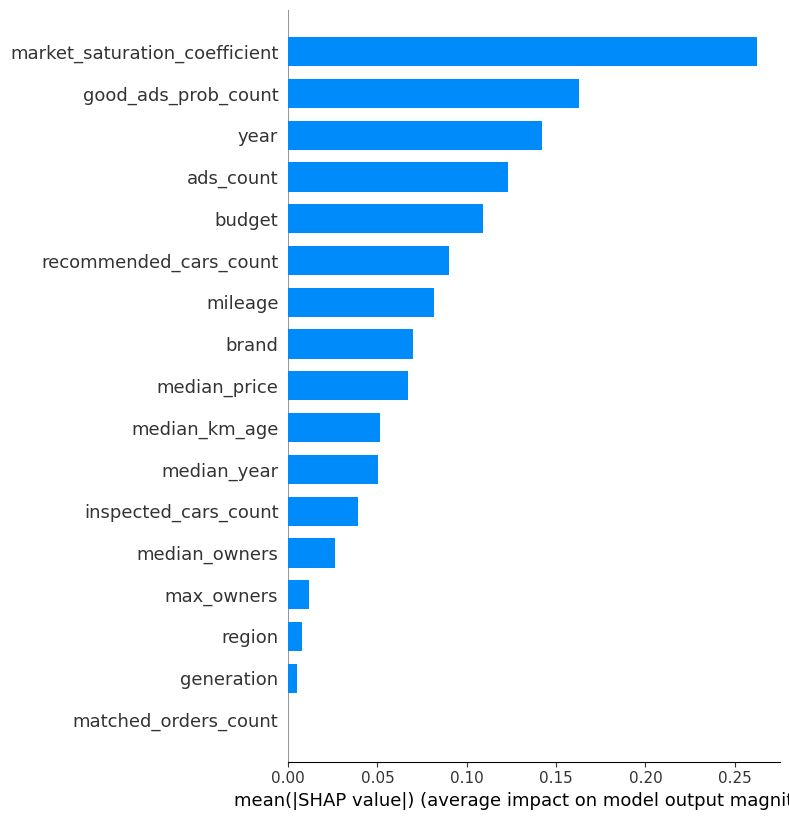

In [403]:
X_test_xg.drop(columns=['xg_verdict','manual_verdict'], inplace=True)
explainer = shap.TreeExplainer(best_xg)
shap_values = explainer.shap_values(X_test_xg)
shap.summary_plot(shap_values, X_test_xg, plot_type="bar")
plt.show()

## Сохранение модели

In [397]:
print(xgb.__version__)
with open('xgb_model_v2.pkl', 'wb') as f:
    pickle.dump(grid_search_xg.best_estimator_, f)

3.1.2


In [251]:
# with open('X_test_xg.pkl', 'wb') as f:
#     pickle.dump(X_test_xg, f)

## Применение gpt

Прироста не дало, больше приведено как пример  возможности

In [ ]:
load_dotenv()
api_key = os.getenv('API_KEY')
URL = os.getenv('BASE_URL')
YA_API_KEY = os.getenv('YA_API_KEY')
YA_CATALOG_ID = os.getenv('YA_CATALOG_ID')

In [ ]:
car_data_modified['desired_criteria'][6]

In [ ]:
car_data_modified['ads_data'][6]

In [ ]:
car_data_modified['ads_count'].describe()

In [ ]:
test_num = 2
desired_criteria = car_data_modified['desired_criteria'][test_num]
ad = car_data_modified['ads_data'][test_num][0]
prompt = f"""Ты — строгий фильтр. Сравни запрос пользователя и описание машины. 
Ответь ТОЛЬКО одним словом: «да» или «нет». Не добавляй ничего другого.

Запрос пользователя:
{desired_criteria}

Описание машины в объявлении:
{ad}"""
print(car_data_modified['ads_count'][test_num])
prompt

In [ ]:
model_path = os.path.abspath("C:\Pavel\llama_cpp\YandexGPT-5-Lite-8B-instruct-Q4_K_M.gguf")


llm = Llama(
    model_path=model_path,
    n_ctx=32768,      # Размер контекста (в токенах)
    n_threads=12,    # Количество потоков CPU
    n_gpu_layers=0, # Количество слоёв на GPU (0 = только CPU)
    verbose=False
)
test_num = 2
desired_criteria = car_data_modified['desired_criteria'][test_num]
print('yandex_gpt_5_lite запущена')
for i, ad in enumerate(car_data_modified['ads_data'][test_num]):
    prompt = f"""
    Ты — строгий фильтр. Сравни запрос пользователя и описание машины.
    Ответь ТОЛЬКО одним словом: «да» или «нет». Не добавляй ничего другого.
    
    Запрос пользователя:
    {desired_criteria}

    Описание машины в объявлении:
    {ad}"""

    response = llm(
        prompt,
        max_tokens=100,
        temperature=0.1,
        top_p=0.2,
        echo=False
    )
    print(f"Ответ модели на {i} объявление:")
    print(response["choices"][0]["text"].strip())
    if i == 2:
        break
llm = None
print('yandex_gpt_5_lite остановлена')

In [ ]:
llm = None
desired_criteria

In [ ]:
car_data_modified['ads_data'][test_num]

In [ ]:
# использование платной API Алисы
# API_URL = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
# API_KEY = YA_API_KEY
# FOLDER_ID = YA_CATALOG_ID

# headers = {
#     "Authorization": f"Api-Key {API_KEY}",
#     "Content-Type": "application/json",
#     "x-folder-id": FOLDER_ID
# }

# data = {
#     "modelUri": f"gpt://{FOLDER_ID}/yandexgpt/latest",
#     "completionOptions": {
#         "temperature": 0.7,
#         "maxTokens": 1000
#     },
#     "messages": [
#         {
#             "role": "user",
#             "text": promt
#         }
#     ]
# }

# response = requests.post(API_URL, headers=headers, json=data)
# print(int(response.json()['result']['usage']['totalTokens']))
# text = response.json()['result']['alternatives'][0]['message']['text'].strip('\n')
# match = re.search(r'\[SPEC_TOKEN_\d+\]', text)
# if match:
#     text = text[:match.start()].strip()
# text = text.strip()
# text